<a href="https://colab.research.google.com/github/SanikaKalyani/mnist-digit-classification-ann/blob/main/notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Training started...

Epoch 0 | Loss: 2.3028 | Accuracy: 7.70%
Epoch 5 | Loss: 2.1070 | Accuracy: 58.98%
Epoch 10 | Loss: 1.0740 | Accuracy: 73.71%
Epoch 15 | Loss: 2.1319 | Accuracy: 28.61%
Epoch 20 | Loss: 1.5690 | Accuracy: 57.88%
Epoch 25 | Loss: 1.3377 | Accuracy: 60.03%
Epoch 30 | Loss: 0.8005 | Accuracy: 73.54%
Epoch 35 | Loss: 0.7377 | Accuracy: 79.54%
Epoch 40 | Loss: 0.7992 | Accuracy: 71.94%
Epoch 45 | Loss: 0.4726 | Accuracy: 84.54%

Training completed!

Test Accuracy: 83.19 %


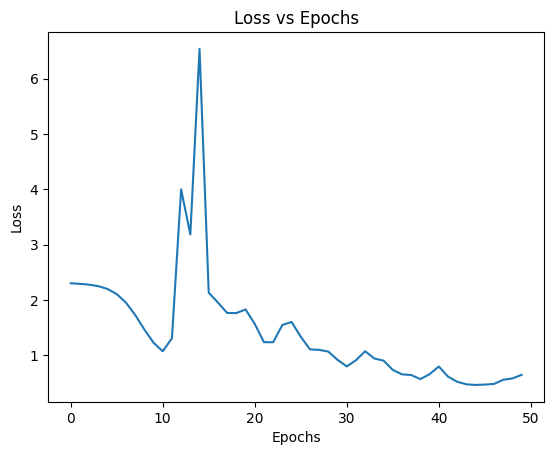

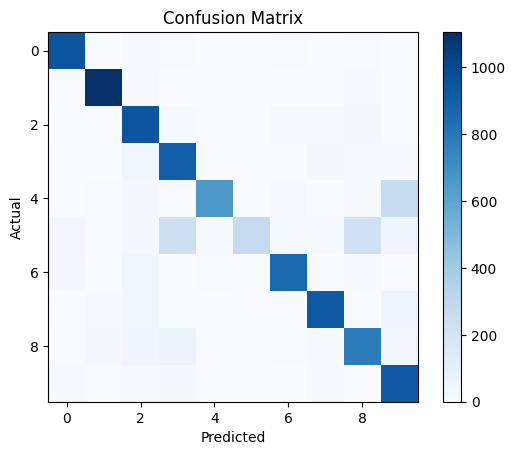


Predicted: 7
Actual: 7


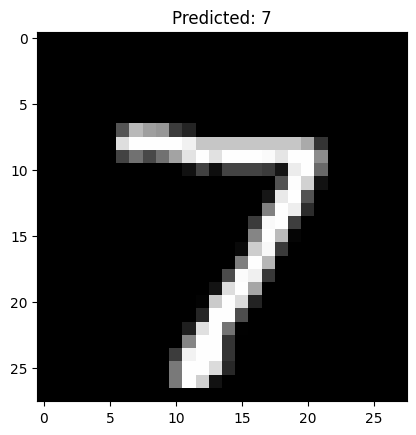

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist


# 1. LOAD DATA

(X_train, y_train), (X_test, y_test) = mnist.load_data()

X_train = X_train.reshape(X_train.shape[0], -1).T / 255.0
X_test = X_test.reshape(X_test.shape[0], -1).T / 255.0

# One-hot encoding
def one_hot(y):
    one_hot_Y = np.zeros((10, y.size))
    one_hot_Y[y, np.arange(y.size)] = 1
    return one_hot_Y

Y_train = one_hot(y_train)


# 2. USE FULL DATA (or reduce if needed)

X = X_train
Y = Y_train


# 3. PARAMETERS

input_size = 784
hidden_size = 128
output_size = 10

np.random.seed(42)

W1 = np.random.randn(hidden_size, input_size) * 0.01
b1 = np.zeros((hidden_size, 1))

W2 = np.random.randn(output_size, hidden_size) * 0.01
b2 = np.zeros((output_size, 1))

# 4. ACTIVATIONS

def relu(Z):
    return np.maximum(0, Z)

def softmax(Z):
    expZ = np.exp(Z - np.max(Z, axis=0, keepdims=True))
    return expZ / np.sum(expZ, axis=0, keepdims=True)


# 5. FORWARD PROPAGATION

def forward(X):
    Z1 = np.dot(W1, X) + b1
    A1 = relu(Z1)

    Z2 = np.dot(W2, A1) + b2
    A2 = softmax(Z2)

    return Z1, A1, Z2, A2


# 6. LOSS
def compute_loss(A2, Y):
    m = Y.shape[1]
    return -np.sum(Y * np.log(A2 + 1e-8)) / m


# 7. BACKPROP
def backward(X, Y, Z1, A1, A2):
    m = X.shape[1]

    dZ2 = A2 - Y
    dW2 = (1/m) * np.dot(dZ2, A1.T)
    db2 = (1/m) * np.sum(dZ2, axis=1, keepdims=True)

    dZ1 = np.dot(W2.T, dZ2)
    dZ1[Z1 <= 0] = 0

    dW1 = (1/m) * np.dot(dZ1, X.T)
    db1 = (1/m) * np.sum(dZ1, axis=1, keepdims=True)

    return dW1, db1, dW2, db2


# 8. UPDATE

def update(lr, dW1, db1, dW2, db2):
    global W1, b1, W2, b2
    W1 -= lr * dW1
    b1 -= lr * db1
    W2 -= lr * dW2
    b2 -= lr * db2


# 9. PREDICTION

def predict(A2):
    return np.argmax(A2, axis=0)

def accuracy(pred, y):
    return np.mean(pred == y) * 100


# 10. TRAINING

epochs = 50
lr = 1

loss_history = []

print("Training started...\n")

for i in range(epochs):

    Z1, A1, Z2, A2 = forward(X)

    loss = compute_loss(A2, Y)
    loss_history.append(loss)

    dW1, db1, dW2, db2 = backward(X, Y, Z1, A1, A2)

    update(lr, dW1, db1, dW2, db2)

    if i % 5 == 0:
        preds = predict(A2)
        acc = accuracy(preds, y_train)
        print(f"Epoch {i} | Loss: {loss:.4f} | Accuracy: {acc:.2f}%")

print("\nTraining completed!")


# 11. TEST ACCURACY

_, _, _, A2_test = forward(X_test)
test_preds = predict(A2_test)

test_acc = accuracy(test_preds, y_test)
print("\nTest Accuracy:", test_acc, "%")


# 12. LOSS GRAPH

plt.plot(loss_history)
plt.title("Loss vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()


# 13. CONFUSION MATRI

cm = np.zeros((10, 10), dtype=int)

for i in range(len(y_test)):
    cm[y_test[i]][test_preds[i]] += 1

plt.imshow(cm, cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()
plt.show()


# 14. TEST SINGLE IMAGE
index = 0
sample = X_test[:, index].reshape(-1, 1)
_, _, _, A2_sample = forward(sample)
prediction = predict(A2_sample)
print("\nPredicted:", prediction[0])
print("Actual:", y_test[index])
plt.imshow(X_test[:, index].reshape(28, 28), cmap='gray')
plt.title(f"Predicted: {prediction[0]}")
plt.show()